In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import json

df_model = pd.read_csv('../data/processed/features_complete.csv')
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 900 non-null    float64
 1   Total_Purchase      900 non-null    float64
 2   Account_Manager     900 non-null    int64  
 3   Years               900 non-null    float64
 4   Num_Sites           900 non-null    float64
 5   Churn               900 non-null    int64  
 6   Onboard_year        900 non-null    int64  
 7   Onboard_month       900 non-null    int64  
 8   Region_Northeast    900 non-null    bool   
 9   Region_South        900 non-null    bool   
 10  Region_Territories  900 non-null    bool   
 11  Region_West         900 non-null    bool   
dtypes: bool(4), float64(4), int64(4)
memory usage: 59.9 KB


In [3]:
#Train/test split
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(720, 11) (180, 11)


In [4]:
#Scaling & baseline logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       150
           1       0.79      0.50      0.61        30

    accuracy                           0.89       180
   macro avg       0.85      0.74      0.78       180
weighted avg       0.89      0.89      0.88       180

[[146   4]
 [ 15  15]]


In [5]:
#Weighted logistic regression
model_weighted = LogisticRegression(random_state=42, class_weight='balanced')
model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)
print(classification_report(y_test, y_pred_weighted))
print(confusion_matrix(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.95      0.85      0.89       150
           1       0.50      0.77      0.61        30

    accuracy                           0.83       180
   macro avg       0.72      0.81      0.75       180
weighted avg       0.87      0.83      0.85       180

[[127  23]
 [  7  23]]


In [6]:
#Threshold sweep - logistic regression
y_proba = model_weighted.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold}: Precision={precision:.2f}, Recall={recall:.2f}")

Threshold 0.3: Precision=0.39, Recall=0.93
Threshold 0.4: Precision=0.44, Recall=0.93
Threshold 0.5: Precision=0.50, Recall=0.77
Threshold 0.6: Precision=0.56, Recall=0.73
Threshold 0.7: Precision=0.66, Recall=0.70


In [7]:
#Random forest & threshold sweep
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_rf_thresh)
    recall = recall_score(y_test, y_pred_rf_thresh)
    print(f"Threshold {threshold}: Precision={precision:.2f}, Recall={recall:.2f}")

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       150
           1       0.66      0.63      0.64        30

    accuracy                           0.88       180
   macro avg       0.79      0.78      0.79       180
weighted avg       0.88      0.88      0.88       180

[[140  10]
 [ 11  19]]
Threshold 0.3: Precision=0.51, Recall=0.80
Threshold 0.4: Precision=0.57, Recall=0.70
Threshold 0.5: Precision=0.67, Recall=0.67
Threshold 0.6: Precision=0.78, Recall=0.60
Threshold 0.7: Precision=0.80, Recall=0.40


               feature  importance
4            Num_Sites    0.380692
3                Years    0.191852
1       Total_Purchase    0.111133
0                  Age    0.089902
6        Onboard_month    0.077611
5         Onboard_year    0.067411
2      Account_Manager    0.024377
9   Region_Territories    0.018157
8         Region_South    0.015360
10         Region_West    0.013043
7     Region_Northeast    0.010462


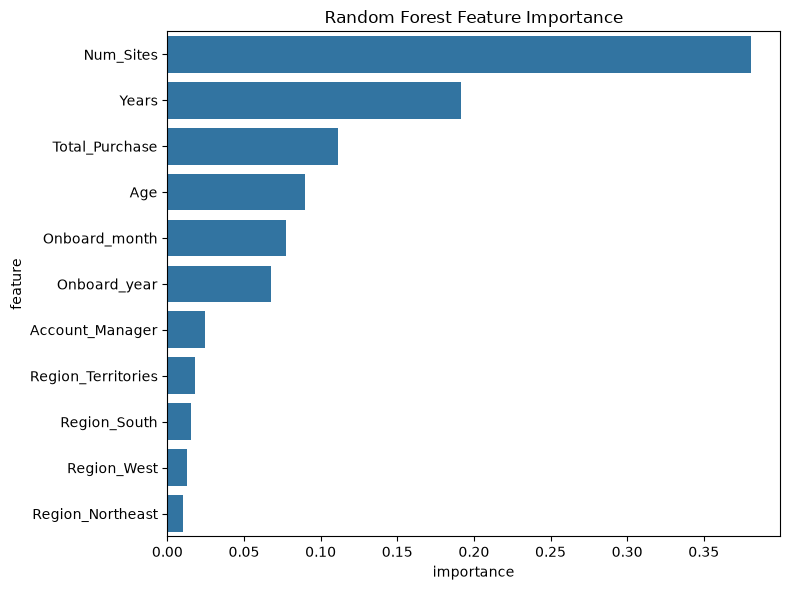

In [8]:
#Feature importance
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

plt.figure(figsize=(8, 6))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [9]:
#Final model save
y_proba_rf_final = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf_final = (y_proba_rf_final >= 0.4).astype(int)

print(classification_report(y_test, y_pred_rf_final))
print(confusion_matrix(y_test, y_pred_rf_final))

joblib.dump(rf_model, '../outputs/churn_model_rf.pkl')

with open('../outputs/model_config.json', 'w') as f:
    json.dump({'threshold': 0.4, 'model': 'RandomForestClassifier', 'class_weight': 'balanced'}, f, indent=2)

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       150
           1       0.57      0.70      0.63        30

    accuracy                           0.86       180
   macro avg       0.75      0.80      0.77       180
weighted avg       0.88      0.86      0.87       180

[[134  16]
 [  9  21]]
